### Assignment-03

- Using the provided ```U-Net``` training notebook as a reference, develop and train a ```DeepLabv3+``` model on the sample dataset available in the ```data``` folder (accessible through the provided Google Drive shortcut).

- For model evaluation, use the same test image that was previously used to evaluate the U-Net model. Save and upload the output image generated by your trained DeepLabv3+ model to the ```data/output``` folder.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from sklearn.model_selection import train_test_split

In [ ]:
os.makedirs("data/images", exist_ok=True)
os.makedirs("data/masks", exist_ok=True)
os.makedirs("data/output", exist_ok=True)

IMG_SIZE = 256
NUM_IMAGES = 20

for i in range(NUM_IMAGES):
    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    center = np.random.randint(60, 200, size=2)
    radius = np.random.randint(25, 50)

    cv2.circle(image, tuple(center), radius, (255,255,255), -1)
    cv2.circle(mask, tuple(center), radius, 255, -1)

    cv2.imwrite(f"data/images/img_{i}.png", image)
    cv2.imwrite(f"data/masks/img_{i}.png", mask)

print("Sample dataset created")


Sample dataset created


In [ ]:
test_image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
cv2.circle(test_image, (128,128), 40, (255,255,255), -1)
cv2.imwrite("data/test_image.png", test_image)

print("Test image created")



Test image created


In [ ]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0
    return np.expand_dims(mask, axis=-1)


In [ ]:
images, masks = [], []

for f in os.listdir("data/images"):
    images.append(load_image(f"data/images/{f}"))
    masks.append(load_mask(f"data/masks/{f}"))

X = np.array(images)
y = np.array(masks)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape, y_train.shape)


Training data: (16, 256, 256, 3) (16, 256, 256, 1)


In [ ]:
def ASPP(inputs):
    y1 = layers.Conv2D(256, 1, padding="same", activation="relu")(inputs)
    y2 = layers.Conv2D(256, 3, dilation_rate=6, padding="same", activation="relu")(inputs)
    y3 = layers.Conv2D(256, 3, dilation_rate=12, padding="same", activation="relu")(inputs)
    y4 = layers.Conv2D(256, 3, dilation_rate=18, padding="same", activation="relu")(inputs)

    y = layers.Concatenate()([y1, y2, y3, y4])
    y = layers.Conv2D(256, 1, padding="same", activation="relu")(y)
    return y


In [ ]:
def DeepLabV3Plus():
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(256, 256, 3)
    )

    # Feature maps
    low_level = base_model.get_layer("conv2_block3_out").output   # 64x64
    encoder_output = base_model.output                            # 16x16 or 32x32

    # ASPP
    aspp = ASPP(encoder_output)

    # ✅ SAFE RESIZE (Keras 3 compatible)
    aspp = layers.Resizing(64, 64, interpolation="bilinear")(aspp)

    # Reduce low-level channels
    low_level = layers.Conv2D(48, 1, padding="same", activation="relu")(low_level)

    # Concatenate (SHAPES NOW MATCH)
    x = layers.Concatenate()([aspp, low_level])

    # Decoder
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    # Final upsampling to input size
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)

    output = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(base_model.input, output)


In [ ]:
model = DeepLabV3Plus()

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 39,834,545 (151.96 MB)

 Trainable params: 39,781,425 (151.75 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
optimizer = keras.optimizers.Adam(1e-4)
loss_fn = keras.losses.BinaryCrossentropy()

EPOCHS = 5    # enough for assignment
BATCH_SIZE = 4

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_dataset = val_dataset.batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Training
    for step, (x_batch, y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)
            loss = loss_fn(y_batch, predictions)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if step % 2 == 0:
            print(f"Step {step} - loss: {loss.numpy():.4f}")

    # Validation
    val_loss = []
    for x_val, y_val in val_dataset:
        val_pred = model(x_val, training=False)
        val_loss.append(loss_fn(y_val, val_pred).numpy())

    print(f"Validation loss: {np.mean(val_loss):.4f}")



Epoch 1/5
Step 0 - loss: 0.7009
Step 2 - loss: 0.2609
Validation loss: 0.3208

Epoch 2/5
Step 0 - loss: 0.0892
Step 2 - loss: 0.0481
Validation loss: 0.4046

Epoch 3/5
Step 0 - loss: 0.0397
Step 2 - loss: 0.0289
Validation loss: 0.4901

Epoch 4/5
Step 0 - loss: 0.0305
Step 2 - loss: 0.0153
Validation loss: 0.6843

Epoch 5/5
Step 0 - loss: 0.0381
Step 2 - loss: 0.0122
Validation loss: 0.6861


In [ ]:
test_img = load_image("data/test_image.png")
test_tensor = tf.convert_to_tensor(
    np.expand_dims(test_img, axis=0),
    dtype=tf.float32
)

# Direct forward pass (SAFE)
prediction = model(test_tensor, training=False)[0]
prediction = (prediction.numpy() > 0.5).astype(np.uint8)


In [ ]:
cv2.imwrite(
    "data/output/deeplabv3plus_output.png",
    prediction * 255
)

print("Output saved to data/output/deeplabv3plus_output.png")


Output saved to data/output/deeplabv3plus_output.png


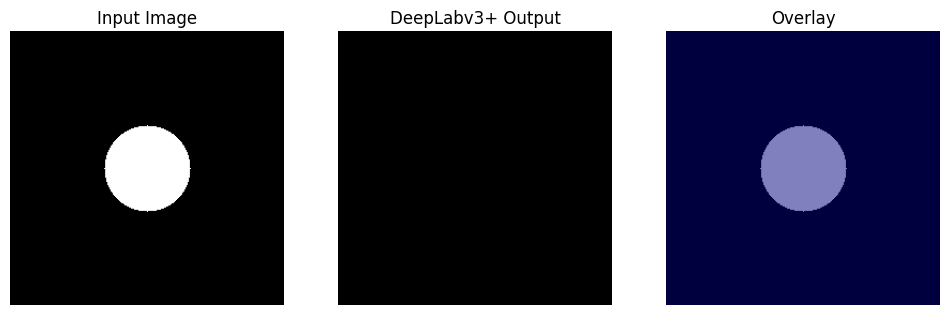

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(test_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("DeepLabv3+ Output")
plt.imshow(prediction.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(test_img)
plt.imshow(prediction.squeeze(), alpha=0.5, cmap="jet")
plt.axis("off")

plt.show()


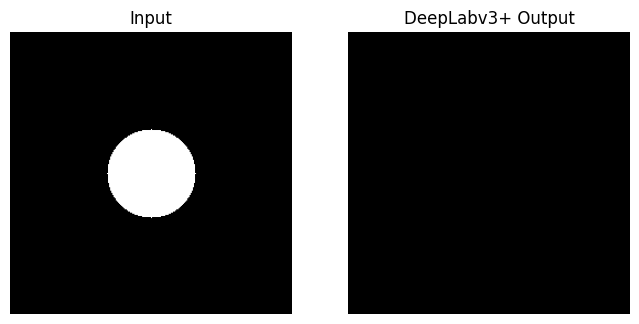

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Input")
plt.imshow(test_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("DeepLabv3+ Output")
plt.imshow(prediction.squeeze(), cmap="gray")
plt.axis("off")

plt.show()
